# Global Ricci - Predictive Experiment (CIFAR-10)

**Reads activations saved by `local_ricci_predictive_experiment_cifar10.ipynb`** and
computes the *global* Ricci coefficient (Baptista et al., arXiv:2404.14265, Eqs. 4-8 + 11).

This notebook does NOT train any model. It expects:
- `OUTPUT_DIR/models/<arch>/epoch_NNNN/layer_*.npy`
- `OUTPUT_DIR/models/<arch>/epoch_history.json`

Per-DNN coefficient (Eq. 8):
$$\rho_k = \mathrm{corr}(\eta_l, \mathrm{Ric}_l), \quad
  \eta_l = g_{l+1} - g_l, \quad
  \mathrm{Ric}_l = \sum_{(i,j)\in E_l} (4 - \deg(i) - \deg(j))$$

Adjusted (Fisher z, Eq. 11):
$$z_k = \mathrm{arctanh}(\rho_k) / \sqrt{L - 4}$$

The global k-sweep range (12.5%, 18.5%, 25%) is taken from the paper's Section 3.2
recommendation for image data.

The companion notebooks share the same `OUTPUT_DIR`:
- `local_ricci_predictive_experiment_cifar10.ipynb` (run this first to produce activations).
- `local_vs_global_comparison_cifar10.ipynb` (combined plots/tables).


In [1]:
import os, time, json, math, glob, random
import numpy as np
from scipy.sparse import csr_matrix, lil_matrix, triu as sp_triu
from scipy.sparse.csgraph import connected_components, shortest_path
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

print(f'numpy : {np.__version__}')


numpy : 2.4.4


/home/zkus/Desktop/izzettin-ismail-cihan/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# -- Reproducibility (only affects any tie-breaking in tools that use rng) --
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -- Must match the LOCAL notebook --
RICCI_EPOCHS = 40

# -- GLOBAL Ricci kNN (Baptista et al. Section 3.2: 12.5%-25% for image data) --
K_GLOBAL_FRAC       = 0.185
K_GLOBAL_FRAC_SWEEP = [0.125, 0.185, 0.25]

# -- kNN graph symmetrization --
GLOBAL_SYMMETRIZE     = 'max'   # 'max' (mutual-OR, undirected default) | 'min' | 'none'
GLOBAL_INCLUDE_INPUT  = False    # paper formula uses hidden-layer representations only
GLOBAL_INCLUDE_OUTPUT = False    # keep output layer out of the hidden-layer Ricci coefficient

# -- Output paths (must match the LOCAL notebook!) --
DRIVE_BASE  = '/home/zkus/Desktop/izzettin-ismail-cihan/18052026'
OUTPUT_DIR  = os.path.join(DRIVE_BASE, 'local_vs_global_ricci_cifar10_v1')
MODELS_DIR  = os.path.join(OUTPUT_DIR, 'models')

if not os.path.isdir(MODELS_DIR):
    raise SystemExit(f'MODELS_DIR not found: {MODELS_DIR}\n'
                     f'  -> run the LOCAL notebook first.')

print(f'Output root : {OUTPUT_DIR}')


Output root : /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1


In [3]:
# -- Detect |X_test| from a saved layer_0.npy (matches LOCAL notebook) --
arch_dirs = sorted(d for d in os.listdir(MODELS_DIR)
                   if os.path.isdir(os.path.join(MODELS_DIR, d)))

N_TEST = None
for d in arch_dirs:
    ep0 = os.path.join(MODELS_DIR, d, 'epoch_0000')
    l0  = os.path.join(ep0, 'layer_0.npy')
    if os.path.exists(l0):
        N_TEST = int(np.load(l0).shape[0])
        break
if N_TEST is None:
    raise SystemExit('No saved activations found. Run the LOCAL notebook first.')

K_GLOBAL       = max(1, int(round(K_GLOBAL_FRAC * N_TEST)))
K_GLOBAL_SWEEP = [max(1, int(round(f * N_TEST))) for f in K_GLOBAL_FRAC_SWEEP]

print(f'Found {len(arch_dirs)} architectures in {MODELS_DIR}')
print(f'Detected |X_test| = {N_TEST}')
print(f'GLOBAL k        = {K_GLOBAL}  ({K_GLOBAL_FRAC*100:.1f}% of {N_TEST})')
print(f'GLOBAL k-sweep  = {K_GLOBAL_SWEEP}  ({K_GLOBAL_FRAC_SWEEP})')


Found 45 architectures in /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/models
Detected |X_test| = 1000
GLOBAL k        = 185  (18.5% of 1000)
GLOBAL k-sweep  = [125, 185, 250]  ([0.125, 0.185, 0.25])


In [4]:
# =============================================================================
# GLOBAL Ricci coefficient   (Baptista et al., arXiv:2404.14265)
# =============================================================================
# Per-DNN scalar:
#   rho_k = corr(eta_l, Ric_l),  l = 1..L-1            (Eq. 8)
#   eta_l = g_{l+1} - g_l                              (Eq. 5)
#   g_l   = sum_{i,j in V} gamma^l_k(i,j)              (Eq. 7)
#   Ric_l = sum_{(i,j) in E^l_k} (4 - deg(i) - deg(j)) (Eqs. 4, 6)
#   z_k   = arctanh(rho_k) / sqrt(L - 4)               (Eq. 11)  Fisher-z
#
# Imported from `knn_fixed_3.py` so replacing that file updates this notebook.
# =============================================================================
from knn_fixed_3 import compute_ricci_coefficient as _compute_global_ricci_coefficient


def compute_global_ricci(features, k,
                          symmetrize=GLOBAL_SYMMETRIZE,
                          include_input=GLOBAL_INCLUDE_INPUT,
                          include_output=GLOBAL_INCLUDE_OUTPUT):
    """Per-DNN global Ricci coefficient (paper Eqs. 4-8 + 11).

    `features`: list of layer activations (default `[input, h1..hL, sigmoid_out]`).
    Returns dict: {r, p, z, L, connected_all, g, Ric, dgs}.
    """
    feats = features
    if not include_input  and len(feats) > 0: feats = feats[1:]
    if not include_output and len(feats) > 0: feats = feats[:-1]

    return _compute_global_ricci_coefficient(feats, k, symmetrize=symmetrize)


print('\u2705 Global Ricci functions defined  (paper Eqs. 4-8 + 11)')


✅ Global Ricci functions defined  (paper Eqs. 4-8 + 11)


In [5]:
def load_json(path, default):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return default

def save_json(path, obj):
    tmp = path + '.tmp'
    with open(tmp, 'w') as f:
        json.dump(obj, f, indent=2)
        f.flush()
        os.fsync(f.fileno())
    os.replace(tmp, path)

def save_activations(epoch_dir, acts):
    os.makedirs(epoch_dir, exist_ok=True)
    for i, act in enumerate(acts):
        path = os.path.join(epoch_dir, f'layer_{i}.npy')
        np.save(path, act)
    dirfd = os.open(epoch_dir, os.O_RDONLY)
    try:
        os.fsync(dirfd)
    finally:
        os.close(dirfd)

print('IO / checkpoint utilities defined (flush-safe)')


IO / checkpoint utilities defined (flush-safe)


In [6]:
# ============================================================================
# GLOBAL RICCI on the activations saved by the LOCAL notebook
# ============================================================================

ckpt_path    = os.path.join(OUTPUT_DIR, 'global_checkpoint.json')
summary_path = os.path.join(OUTPUT_DIR, 'summary_global.json')

ckpt    = load_json(ckpt_path,    {'completed': []})
summary = load_json(summary_path, [])
completed = set(ckpt['completed'])


def _layer_files(ep_dir):
    fs = [f for f in os.listdir(ep_dir)
          if f.startswith('layer_') and f.endswith('.npy')
          and not f.startswith('layer_ricci')]
    fs.sort(key=lambda s: int(s.split('_')[1].split('.')[0]))
    return [os.path.join(ep_dir, f) for f in fs]


def _parse_arch_name(name):
    parts = name.split('_')
    if len(parts) < 3:
        return None
    try:
        return parts[0], int(parts[1]), int(parts[2])
    except ValueError:
        return None


t_start = time.time()

for arch_idx, name in enumerate(arch_dirs):

    if name in completed:
        print(f'[{arch_idx+1:2d}/{len(arch_dirs)}] {name} -- skipped (checkpoint)')
        continue

    arch_dir  = os.path.join(MODELS_DIR, name)
    hist_path = os.path.join(arch_dir, 'epoch_history.json')
    if not os.path.exists(hist_path):
        print(f'[{arch_idx+1:2d}/{len(arch_dirs)}] {name} -- no epoch_history; skip')
        continue
    epoch_history = load_json(hist_path, [])

    info = _parse_arch_name(name)
    if info is None:
        print(f'[{arch_idx+1:2d}/{len(arch_dirs)}] {name} -- cannot parse; skip')
        continue
    arch_type, depth, width = info

    print(f'\n[{arch_idx+1:2d}/{len(arch_dirs)}] {name}'
          f'  type={arch_type}  depth={depth}  width={width}')

    per_epoch_r, per_epoch_z = [], []
    per_epoch_connected = []

    for epoch in range(RICCI_EPOCHS):
        ep_dir = os.path.join(arch_dir, f'epoch_{epoch:04d}')
        if not os.path.isdir(ep_dir):
            continue
        paths = _layer_files(ep_dir)
        if len(paths) < 3:
            continue

        feats  = [np.load(p) for p in paths]
        gstats = compute_global_ricci(
            feats, K_GLOBAL,
            symmetrize=GLOBAL_SYMMETRIZE,
            include_input=GLOBAL_INCLUDE_INPUT,
            include_output=GLOBAL_INCLUDE_OUTPUT)

        per_epoch_r.append(gstats['r'] if gstats['r'] is not None else float('nan'))
        per_epoch_z.append(gstats['z'] if gstats['z'] is not None else float('nan'))
        per_epoch_connected.append(bool(gstats['connected_all']))

        save_json(os.path.join(ep_dir, 'global_ricci.json'), gstats)

        r_str = f"{gstats['r']:+.4f}" if gstats['r'] is not None else '   None'
        z_str = f"{gstats['z']:+.3f}" if gstats['z'] is not None else '  None'
        print(f'  ep {epoch:3d}  r={r_str}  z={z_str}  '
              f'connected_all={gstats["connected_all"]}  L={gstats["L"]}')

    if not per_epoch_r:
        completed.add(name)
        save_json(ckpt_path, {'completed': sorted(completed)})
        continue

    all_test_accs = [e['test_acc'] for e in epoch_history]

    entry = {
        'name':                            name,
        'type':                            arch_type,
        'depth':                           depth,
        'width':                           width,
        'early_global_ricci_r':            float(np.nanmean(per_epoch_r)),
        'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
        'early_global_ricci_r_per_epoch':  per_epoch_r,
        'early_global_ricci_z_per_epoch':  per_epoch_z,
        'global_connected_per_epoch':      per_epoch_connected,
        'long_term_acc':                   float(np.mean(all_test_accs)),
        'final_acc':                       float(epoch_history[-1]['test_acc']),
        'best_acc':                        float(max(all_test_accs)),
        'best_acc_epoch':                  int(np.argmax(all_test_accs)),
        'k_global':                        K_GLOBAL,
        'k_global_frac':                   K_GLOBAL_FRAC,
    }
    summary.append(entry)
    save_json(summary_path, summary)

    completed.add(name)
    save_json(ckpt_path, {'completed': sorted(completed)})

    print(f'  -> r={entry["early_global_ricci_r"]:+.4f}'
          f'  z={entry["early_global_ricci_z"]:+.4f}'
          f'  long_term_acc={entry["long_term_acc"]:.4f}')

print(f'\nGlobal Ricci computation complete in {(time.time()-t_start)/60:.1f} min.')
print(f'   {len(summary)} architectures saved to {summary_path}')



[ 1/45] bottleneck_10_128  type=bottleneck  depth=10  width=128
  ep   0  r=-0.4446  z=-0.195  connected_all=True  L=10
  ep   1  r=-0.2853  z=-0.120  connected_all=True  L=10
  ep   2  r=-0.6061  z=-0.287  connected_all=True  L=10
  ep   3  r=-0.2449  z=-0.102  connected_all=True  L=10
  ep   4  r=-0.4049  z=-0.175  connected_all=True  L=10
  ep   5  r=-0.3537  z=-0.151  connected_all=True  L=10
  ep   6  r=-0.1819  z=-0.075  connected_all=True  L=10
  ep   7  r=-0.3743  z=-0.161  connected_all=True  L=10
  ep   8  r=-0.3465  z=-0.148  connected_all=True  L=10
  ep   9  r=-0.2737  z=-0.115  connected_all=True  L=10
  ep  10  r=-0.3213  z=-0.136  connected_all=True  L=10
  ep  11  r=-0.2475  z=-0.103  connected_all=True  L=10
  ep  12  r=-0.3007  z=-0.127  connected_all=True  L=10
  ep  13  r=-0.2554  z=-0.107  connected_all=True  L=10
  ep  14  r=-0.2891  z=-0.121  connected_all=True  L=10
  ep  15  r=-0.3445  z=-0.147  connected_all=True  L=10
  ep  16  r=-0.2439  z=-0.102  connecte

/tmp/ipykernel_3193023/4081327391.py:97: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),


  ep   0  r=+0.4153  z=+0.442  connected_all=True  L=5
  ep   1  r=+0.1564  z=+0.158  connected_all=True  L=5
  ep   2  r=-0.2217  z=-0.225  connected_all=True  L=5
  ep   3  r=-0.4495  z=-0.484  connected_all=True  L=5
  ep   4  r=-0.6731  z=-0.816  connected_all=True  L=5
  ep   5  r=-0.7054  z=-0.878  connected_all=True  L=5
  ep   6  r=-0.7539  z=-0.982  connected_all=True  L=5
  ep   7  r=-0.6957  z=-0.859  connected_all=True  L=5
  ep   8  r=-0.5806  z=-0.663  connected_all=True  L=5
  ep   9  r=-0.7373  z=-0.945  connected_all=True  L=5
  ep  10  r=-0.6519  z=-0.779  connected_all=True  L=5
  ep  11  r=-0.6367  z=-0.753  connected_all=True  L=5
  ep  12  r=-0.7466  z=-0.965  connected_all=True  L=5
  ep  13  r=-0.7367  z=-0.943  connected_all=True  L=5
  ep  14  r=-0.7949  z=-1.085  connected_all=True  L=5
  ep  15  r=-0.7064  z=-0.880  connected_all=True  L=5
  ep  16  r=-0.7601  z=-0.996  connected_all=True  L=5
  ep  17  r=-0.7160  z=-0.899  connected_all=True  L=5
  ep  18  

/tmp/ipykernel_3193023/4081327391.py:97: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),


  ep   0  r=-0.9199  z=  None  connected_all=True  L=4
  ep   1  r=-0.8274  z=  None  connected_all=True  L=4
  ep   2  r=-0.9853  z=  None  connected_all=True  L=4
  ep   3  r=-0.8346  z=  None  connected_all=True  L=4
  ep   4  r=-0.9321  z=  None  connected_all=True  L=4
  ep   5  r=-0.7195  z=  None  connected_all=True  L=4
  ep   6  r=-0.5681  z=  None  connected_all=True  L=4
  ep   7  r=-0.6359  z=  None  connected_all=True  L=4
  ep   8  r=-0.7512  z=  None  connected_all=True  L=4
  ep   9  r=-0.7902  z=  None  connected_all=True  L=4
  ep  10  r=-0.6872  z=  None  connected_all=True  L=4
  ep  11  r=-0.7091  z=  None  connected_all=True  L=4
  ep  12  r=-0.8361  z=  None  connected_all=True  L=4
  ep  13  r=-0.6809  z=  None  connected_all=True  L=4
  ep  14  r=-0.7049  z=  None  connected_all=True  L=4
  ep  15  r=-0.8004  z=  None  connected_all=True  L=4
  ep  16  r=-0.7493  z=  None  connected_all=True  L=4
  ep  17  r=-0.7165  z=  None  connected_all=True  L=4
  ep  18  

...

  ep   0  r=-0.9912  z=  None  connected_all=True  L=4
  ep   1  r=-0.9292  z=  None  connected_all=True  L=4
  ep   2  r=-0.9984  z=  None  connected_all=True  L=4
  ep   3  r=-0.8174  z=  None  connected_all=True  L=4
  ep   4  r=-0.9807  z=  None  connected_all=True  L=4
  ep   5  r=-0.7743  z=  None  connected_all=True  L=4
  ep   6  r=-0.9482  z=  None  connected_all=True  L=4
  ep   7  r=-0.9953  z=  None  connected_all=True  L=4
  ep   8  r=-0.6048  z=  None  connected_all=True  L=4
  ep   9  r=-0.6964  z=  None  connected_all=True  L=4
  ep  10  r=-0.8871  z=  None  connected_all=True  L=4
  ep  11  r=-0.8526  z=  None  connected_all=True  L=4
  ep  12  r=-0.9954  z=  None  connected_all=True  L=4
  ep  13  r=-0.9920  z=  None  connected_all=True  L=4
  ep  14  r=-0.9983  z=  None  connected_all=True  L=4
  ep  15  r=-0.6817  z=  None  connected_all=True  L=4
  ep  16  r=-0.9881  z=  None  connected_all=True  L=4
  ep  17  r=-0.9640  z=  None  connected_all=True  L=4
  ep  18  

/tmp/ipykernel_3193023/4081327391.py:97: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),


  ep   0  r=-0.5198  z=  None  connected_all=True  L=4
  ep   1  r=-0.8065  z=  None  connected_all=True  L=4
  ep   2  r=-0.5939  z=  None  connected_all=True  L=4
  ep   3  r=-0.9321  z=  None  connected_all=True  L=4
  ep   4  r=-0.9778  z=  None  connected_all=True  L=4
  ep   5  r=-0.8651  z=  None  connected_all=True  L=4
  ep   6  r=-0.9728  z=  None  connected_all=True  L=4
  ep   7  r=-0.8646  z=  None  connected_all=True  L=4
  ep   8  r=-0.9956  z=  None  connected_all=True  L=4
  ep   9  r=-0.9812  z=  None  connected_all=True  L=4
  ep  10  r=-0.9996  z=  None  connected_all=True  L=4
  ep  11  r=-0.9617  z=  None  connected_all=True  L=4
  ep  12  r=-0.8955  z=  None  connected_all=True  L=4
  ep  13  r=-0.9969  z=  None  connected_all=True  L=4
  ep  14  r=-0.9404  z=  None  connected_all=True  L=4
  ep  15  r=-0.8737  z=  None  connected_all=True  L=4
  ep  16  r=-0.9798  z=  None  connected_all=True  L=4
  ep  17  r=-0.7841  z=  None  connected_all=True  L=4
  ep  18  

/tmp/ipykernel_3193023/4081327391.py:97: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),


  ep   0  r=-0.3595  z=-0.376  connected_all=True  L=5
  ep   1  r=+0.1036  z=+0.104  connected_all=True  L=5
  ep   2  r=-0.0598  z=-0.060  connected_all=True  L=5
  ep   3  r=-0.0366  z=-0.037  connected_all=True  L=5
  ep   4  r=+0.0070  z=+0.007  connected_all=True  L=5
  ep   5  r=+0.1764  z=+0.178  connected_all=True  L=5
  ep   6  r=+0.6090  z=+0.707  connected_all=True  L=5
  ep   7  r=+0.4481  z=+0.482  connected_all=True  L=5
  ep   8  r=-0.0647  z=-0.065  connected_all=True  L=5
  ep   9  r=+0.2100  z=+0.213  connected_all=True  L=5
  ep  10  r=+0.7339  z=+0.937  connected_all=True  L=5
  ep  11  r=+0.5125  z=+0.566  connected_all=True  L=5
  ep  12  r=+0.4201  z=+0.448  connected_all=True  L=5
  ep  13  r=+0.4057  z=+0.430  connected_all=True  L=5
  ep  14  r=+0.3221  z=+0.334  connected_all=True  L=5
  ep  15  r=+0.4347  z=+0.466  connected_all=True  L=5
  ep  16  r=+0.4707  z=+0.511  connected_all=True  L=5
  ep  17  r=+0.4506  z=+0.485  connected_all=True  L=5
  ep  18  

In [7]:
# -- GLOBAL Ricci correlations: Early r/z vs Long-Term Accuracy --
summary = load_json(os.path.join(OUTPUT_DIR, 'summary_global.json'), [])
if not summary:
    print('Run the global computation cell first.')
else:
    g_r_arr = np.array([r['early_global_ricci_r'] for r in summary])
    g_z_arr = np.array([r['early_global_ricci_z'] for r in summary])
    lt_arr  = np.array([r['long_term_acc']        for r in summary])

    print('=' * 70)
    print('GLOBAL RICCI vs LONG-TERM ACCURACY  (CIFAR-10 Cars vs Planes)')
    print('=' * 70)
    print('sign convention: positive r/rho/tau = more negative Ricci predicts higher acc')
    print('-' * 70)

    results_global = {
        'dataset':         'CIFAR-10 Cars vs Planes',
        'sign_convention': 'positive = more negative ricci predicts higher acc',
        'n':               len(summary),
        'k_global':        int(K_GLOBAL),
        'k_global_frac':   K_GLOBAL_FRAC,
    }
    for label, arr in [('raw_r', g_r_arr), ('fisher_z', g_z_arr)]:
        mask = np.isfinite(arr) & np.isfinite(lt_arr)
        if mask.sum() < 2:
            print(f'  {label:>9}  -- too few finite values --')
            continue
        x = -arr[mask]
        y =  lt_arr[mask]
        pr,  pp  = pearsonr(x, y)
        sr,  sp  = spearmanr(x, y)
        kt,  kp  = kendalltau(x, y)
        print(f'  {label:>9}  (n={int(mask.sum())})')
        print(f'    Pearson  r   = {pr:+.4f}   p = {pp:.4f}')
        print(f'    Spearman rho = {sr:+.4f}   p = {sp:.4f}')
        print(f'    Kendall  tau = {kt:+.4f}   p = {kp:.4f}')
        results_global[label] = {
            'n':           int(mask.sum()),
            'pearson_r':   float(pr), 'pearson_p':   float(pp),
            'spearman_r':  float(sr), 'spearman_p':  float(sp),
            'kendall_tau': float(kt), 'kendall_p':   float(kp),
        }
    print('=' * 70)
    save_json(os.path.join(OUTPUT_DIR, 'correlation_results_global.json'), results_global)
    print(f'Saved -> {os.path.join(OUTPUT_DIR, "correlation_results_global.json")}')


GLOBAL RICCI vs LONG-TERM ACCURACY  (CIFAR-10 Cars vs Planes)
sign convention: positive r/rho/tau = more negative Ricci predicts higher acc
----------------------------------------------------------------------
      raw_r  (n=45)
    Pearson  r   = -0.3255   p = 0.0291
    Spearman rho = -0.3829   p = 0.0094
    Kendall  tau = -0.2566   p = 0.0130
   fisher_z  (n=40)
    Pearson  r   = -0.2933   p = 0.0662
    Spearman rho = -0.4867   p = 0.0015
    Kendall  tau = -0.3205   p = 0.0036
Saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/correlation_results_global.json


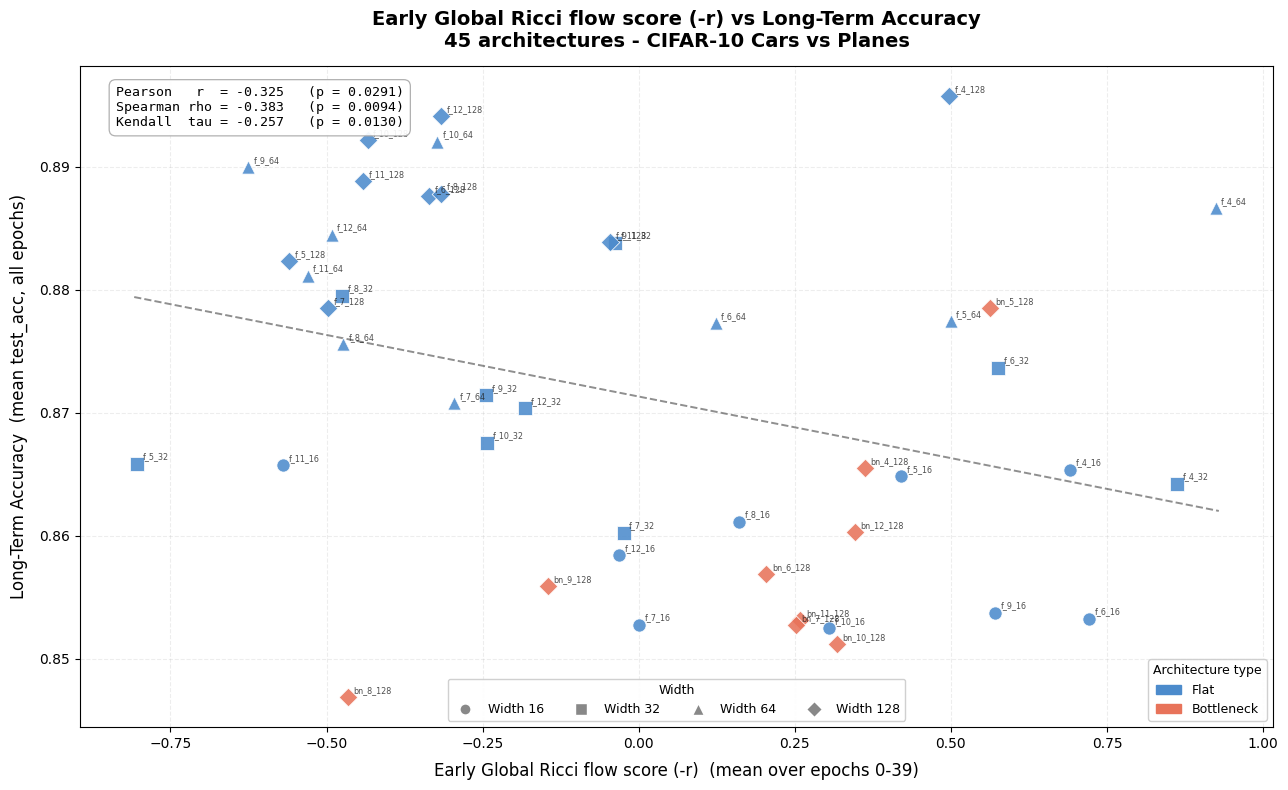

Saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/global_ricci_flow_r_vs_acc_scatter.png


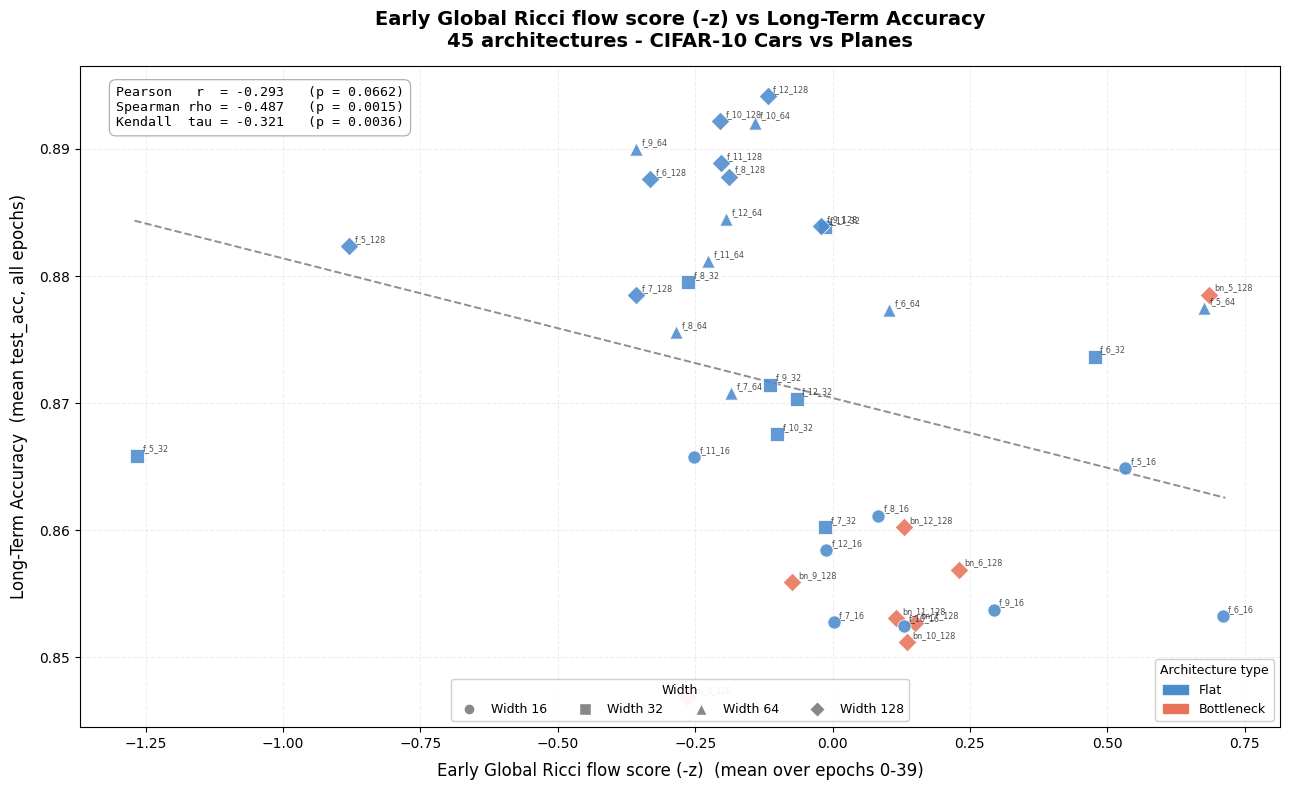

Saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/global_ricci_flow_z_vs_acc_scatter.png


In [8]:
# -- Scatter: early global Ricci flow score (-r and -z) vs long-term accuracy --
summary = load_json(os.path.join(OUTPUT_DIR, 'summary_global.json'), [])
corr    = load_json(os.path.join(OUTPUT_DIR, 'correlation_results_global.json'), {})

if not summary:
    print('Run the global computation and correlation cells first.')
else:
    type_color   = {'flat': '#4C8BCC', 'bottleneck': '#E8735A'}
    width_marker = {16: 'o', 32: 's', 64: '^', 128: 'D'}

    plot_specs = [
        ('early_global_ricci_r', 'raw_r',    'Global Ricci flow score (-r)', 'flow_r'),
        ('early_global_ricci_z', 'fisher_z', 'Global Ricci flow score (-z)', 'flow_z'),
    ]

    for ricci_key, corr_key, label, savetag in plot_specs:
        r_arr = np.array([r[ricci_key]       for r in summary])
        score_arr = -r_arr
        a_arr = np.array([r['long_term_acc'] for r in summary])
        mask  = np.isfinite(r_arr) & np.isfinite(a_arr)
        if mask.sum() < 2:
            print(f'{label} -- too few finite values'); continue

        fig, ax = plt.subplots(figsize=(13, 8))

        for r in summary:
            v = r.get(ricci_key)
            if v is None or not np.isfinite(v):
                continue
            ax.scatter(-v, r['long_term_acc'],
                       color=type_color[r['type']],
                       marker=width_marker[r['width']],
                       s=90, alpha=0.88, edgecolors='white',
                       linewidths=0.6, zorder=3)

        x = score_arr[mask]; y = a_arr[mask]
        m, b = np.polyfit(x, y, 1)
        xr = np.linspace(x.min() - 0.005, x.max() + 0.005, 300)
        ax.plot(xr, m * xr + b, color='#333333',
                lw=1.4, ls='--', alpha=0.55, zorder=2)

        for r in summary:
            v = r.get(ricci_key)
            if v is None or not np.isfinite(v):
                continue
            short = r['name'].replace('bottleneck_', 'bn_').replace('flat_', 'f_')
            ax.annotate(short, (-v, r['long_term_acc']),
                        xytext=(4, 3), textcoords='offset points',
                        fontsize=5.8, alpha=0.80, color='#222222')

        if corr and corr_key in corr:
            c = corr[corr_key]
            box = (f"Pearson   r  = {c['pearson_r']:+.3f}   (p = {c['pearson_p']:.4f})\n"
                   f"Spearman rho = {c['spearman_r']:+.3f}   (p = {c['spearman_p']:.4f})\n"
                   f"Kendall  tau = {c['kendall_tau']:+.3f}   (p = {c['kendall_p']:.4f})")
            ax.text(0.03, 0.97, box, transform=ax.transAxes, fontsize=9.5,
                    verticalalignment='top', family='monospace',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                              edgecolor='#AAAAAA', linewidth=0.9, alpha=0.92))

        type_legend = [mpatches.Patch(color='#4C8BCC', label='Flat'),
                       mpatches.Patch(color='#E8735A', label='Bottleneck')]
        width_legend = [
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#888', markersize=8, label='Width 16'),
            plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#888', markersize=8, label='Width 32'),
            plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='#888', markersize=8, label='Width 64'),
            plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='#888', markersize=8, label='Width 128'),
        ]
        leg1 = ax.legend(handles=type_legend, loc='lower right',
                         fontsize=9, title='Architecture type',
                         title_fontsize=9, framealpha=0.92)
        ax.add_artist(leg1)
        ax.legend(handles=width_legend, loc='lower center',
                  fontsize=9, title='Width', title_fontsize=9,
                  framealpha=0.92, ncol=4)

        ax.set_xlabel(f'Early {label}  (mean over epochs 0-{RICCI_EPOCHS-1})',
                      fontsize=12, labelpad=8)
        ax.set_ylabel('Long-Term Accuracy  (mean test_acc, all epochs)',
                      fontsize=12, labelpad=8)
        ax.set_title(f'Early {label} vs Long-Term Accuracy\n'
                     '45 architectures - CIFAR-10 Cars vs Planes',
                     fontsize=14, fontweight='bold', pad=14)
        ax.grid(True, alpha=0.22, linestyle='--')
        ax.set_axisbelow(True)
        plt.tight_layout()
        save_path = os.path.join(OUTPUT_DIR, f'global_ricci_{savetag}_vs_acc_scatter.png')
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f'Saved -> {save_path}')


In [9]:
import csv

summary = load_json(os.path.join(OUTPUT_DIR, 'summary_global.json'), [])
if not summary:
    print('Run the global computation cell first.')
else:
    r_scores = [r['early_global_ricci_r'] for r in summary]
    z_scores = [r['early_global_ricci_z'] for r in summary]
    lt_accs  = [r['long_term_acc']        for r in summary]

    r_rank   = {summary[i]['name']: int(rk) + 1
                for rk, i in enumerate(np.argsort(r_scores))}
    z_rank   = {summary[i]['name']: int(rk) + 1
                for rk, i in enumerate(np.argsort(z_scores))}
    acc_rank = {summary[i]['name']: int(rk) + 1
                for rk, i in enumerate(np.argsort(lt_accs)[::-1])}

    rows = []
    for r in summary:
        rows.append({
            'name':                  r['name'],
            'type':                  r['type'],
            'depth':                 r['depth'],
            'width':                 r['width'],
            'early_global_ricci_r':  round(r['early_global_ricci_r'], 6),
            'early_global_ricci_z':  round(r['early_global_ricci_z'], 6),
            'r_rank':                r_rank[r['name']],
            'z_rank':                z_rank[r['name']],
            'long_term_acc':         round(r['long_term_acc'], 6),
            'acc_rank':              acc_rank[r['name']],
            'final_acc':             round(r['final_acc'], 6),
            'best_acc':              round(r['best_acc'], 6),
            'best_acc_epoch':        r['best_acc_epoch'],
        })
    rows.sort(key=lambda x: x['acc_rank'])

    csv_path = os.path.join(OUTPUT_DIR, 'global_ricci_predictive_results.csv')
    with open(csv_path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        w.writeheader(); w.writerows(rows)
    print(f'Saved {len(rows)} rows -> {csv_path}')

    print(f'\n{"Rank":>4}  {"Architecture":<26}  {"r":>10}  {"z":>10}  {"LT Acc":>8}')
    print('-' * 68)
    head_tail = rows[:10] + [None] + rows[-10:] if len(rows) > 25 else rows
    for row in head_tail:
        if row is None:
            print('  ...'); continue
        print(f'{row["acc_rank"]:>4}  {row["name"]:<26}  '
              f'{row["early_global_ricci_r"]:>+10.4f}  '
              f'{row["early_global_ricci_z"]:>+10.4f}  '
              f'{row["long_term_acc"]:>8.4f}')


Saved 45 rows -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/global_ricci_predictive_results.csv

Rank  Architecture                         r           z    LT Acc
--------------------------------------------------------------------
   1  flat_4_128                     -0.4973        +nan    0.8957
   2  flat_12_128                    +0.3169     +0.1182    0.8941
   3  flat_10_128                    +0.4343     +0.2047    0.8922
   4  flat_10_64                     +0.3230     +0.1419    0.8921
   5  flat_9_64                      +0.6259     +0.3569    0.8900
   6  flat_11_128                    +0.4418     +0.2029    0.8889
   7  flat_8_128                     +0.3160     +0.1883    0.8878
   8  flat_6_128                     +0.3359     +0.3321    0.8876
   9  flat_4_64                      -0.9241        +nan    0.8867
  10  flat_12_64                     +0.4917     +0.1940    0.8845
  ...
  36  bottleneck_6_128               -0.2043     -0

## k-sweep on saved activations -- GLOBAL Ricci

Recompute the **global** Ricci coefficient (paper Eqs. 4-8 + Fisher-z) at multiple
`K_GLOBAL_FRAC` values **without retraining**. Uses the per-epoch `layer_*.npy`
activations saved during training, so all k values are evaluated on identical
activations -> fair k-comparison.

Outputs:
- `summary_global_k{xxx}.json` per swept k (e.g. `summary_global_k125.json` for 12.5%)
- `correlation_results_global_k{xxx}.json` per swept k  (raw r AND Fisher-z)
- per-epoch `global_ricci_k{xxx}.json` written next to the saved activations


In [10]:
# ---- k-sweep for GLOBAL Ricci on saved activations ----
# Self-contained: redefines the small helpers so this cell runs even if the
# LOCAL k-sweep cell above hasn't been executed in the same session.

def _layer_files(ep_dir):
    fs = [f for f in os.listdir(ep_dir)
          if f.startswith('layer_') and f.endswith('.npy')
          and not f.startswith('layer_ricci')]
    fs.sort(key=lambda s: int(s.split('_')[1].split('.')[0]))
    return [os.path.join(ep_dir, f) for f in fs]

def _tag(frac):
    return f"{int(round(frac * 1000)):03d}"


arch_dirs = sorted(d for d in os.listdir(MODELS_DIR)
                   if os.path.isdir(os.path.join(MODELS_DIR, d)))

print(f'Found {len(arch_dirs)} architectures in {MODELS_DIR}')

for frac in K_GLOBAL_FRAC_SWEEP:
    k_g = max(1, int(round(frac * N_TEST)))
    tag = _tag(frac)
    print(f'\n=== GLOBAL Ricci   K_GLOBAL_FRAC = {frac:.2%}  (k = {k_g}) ===')

    sweep_ckpt_path = os.path.join(OUTPUT_DIR, f'sweep_global_checkpoint_k{tag}.json')
    out_summary     = os.path.join(OUTPUT_DIR, f'summary_global_k{tag}.json')

    sweep_ckpt = load_json(sweep_ckpt_path, {'completed': []})
    summary_g  = load_json(out_summary, [])
    completed_arch = set(sweep_ckpt.get('completed', []))

    if completed_arch:
        print(f'  resuming from checkpoint: {len(completed_arch)} '
              f'/ {len(arch_dirs)} architectures already done')

    for name in tqdm(arch_dirs, desc=f'global k={k_g}'):
        if name in completed_arch:
            continue

        arch_dir  = os.path.join(MODELS_DIR, name)
        hist_path = os.path.join(arch_dir, 'epoch_history.json')
        if not os.path.exists(hist_path):
            continue
        epoch_history = load_json(hist_path, [])

        per_epoch_r = []
        per_epoch_z = []
        for epoch in range(RICCI_EPOCHS):
            ep_dir = os.path.join(arch_dir, f'epoch_{epoch:04d}')
            if not os.path.isdir(ep_dir):
                continue
            paths = _layer_files(ep_dir)
            if len(paths) < 3:
                continue
            feats = [np.load(p) for p in paths]
            gstats = compute_global_ricci(feats, k_g,
                                          symmetrize=GLOBAL_SYMMETRIZE,
                                          include_input=GLOBAL_INCLUDE_INPUT,
                                          include_output=GLOBAL_INCLUDE_OUTPUT)
            per_epoch_r.append(gstats['r'] if gstats['r'] is not None else float('nan'))
            per_epoch_z.append(gstats['z'] if gstats['z'] is not None else float('nan'))
            save_json(os.path.join(ep_dir, f'global_ricci_k{tag}.json'), gstats)

        if not per_epoch_r:
            continue

        parts = name.split('_')
        atype, depth, width = parts[0], int(parts[1]), int(parts[2])
        all_test_accs = [e['test_acc'] for e in epoch_history]

        summary_g.append({
            'name': name, 'type': atype, 'depth': depth, 'width': width,
            'early_global_ricci_r':            float(np.nanmean(per_epoch_r)),
            'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
            'early_global_ricci_r_per_epoch':  per_epoch_r,
            'early_global_ricci_z_per_epoch':  per_epoch_z,
            'long_term_acc':                   float(np.mean(all_test_accs)),
            'final_acc':                       float(epoch_history[-1]['test_acc']),
            'best_acc':                        float(max(all_test_accs)),
            'best_acc_epoch':                  int(np.argmax(all_test_accs)),
            'k_global_frac':                   frac,
            'k_global':                        k_g,
        })

        save_json(out_summary, summary_g)
        completed_arch.add(name)
        save_json(sweep_ckpt_path, {'completed': sorted(completed_arch),
                                    'k_global_frac': frac, 'k_global': k_g})

    print(f'  saved -> {out_summary}  ({len(summary_g)} architectures)')

    if len(summary_g) >= 2:
        r_arr = np.array([s['early_global_ricci_r'] for s in summary_g])
        z_arr = np.array([s['early_global_ricci_z'] for s in summary_g])
        a_arr = np.array([s['long_term_acc']        for s in summary_g])

        corr = {'k_global_frac': frac, 'k_global': k_g, 'n': len(summary_g),
                'sign_convention': 'positive = more negative ricci predicts higher acc'}
        for label, arr in [('raw_r', r_arr), ('fisher_z', z_arr)]:
            mask = np.isfinite(arr) & np.isfinite(a_arr)
            if mask.sum() < 2:
                continue
            x  = -arr[mask]
            y  =  a_arr[mask]
            pr, pp = pearsonr(x, y)
            sr, sp = spearmanr(x, y)
            kt, kp = kendalltau(x, y)
            corr[label] = {'n': int(mask.sum()),
                           'pearson_r':   float(pr), 'pearson_p':   float(pp),
                           'spearman_r':  float(sr), 'spearman_p':  float(sp),
                           'kendall_tau': float(kt), 'kendall_p':   float(kp)}
            print(f'  [{label:>8}]  Pearson r={pr:+.4f} (p={pp:.4f})  '
                  f'Spearman rho={sr:+.4f} (p={sp:.4f})  '
                  f'Kendall tau={kt:+.4f} (p={kp:.4f})')

        save_json(os.path.join(OUTPUT_DIR,
                               f'correlation_results_global_k{tag}.json'), corr)

print('\nGLOBAL k-sweep done.')


Found 45 architectures in /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/models

=== GLOBAL Ricci   K_GLOBAL_FRAC = 12.50%  (k = 125) ===


global k=125:   7%|▋         | 3/45 [08:37<2:02:57, 175.64s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=125:  47%|████▋     | 21/45 [55:51<1:16:34, 191.43s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=125:  49%|████▉     | 22/45 [57:00<59:19, 154.77s/it]  /tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=125:  51%|█████     | 23/45 [58:06<47:02, 128.31s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=125:  53%|█████▎    | 24/45 [59:14<38:30, 110.02s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':    

  saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/summary_global_k125.json  (45 architectures)
  [   raw_r]  Pearson r=-0.3582 (p=0.0157)  Spearman rho=-0.4406 (p=0.0025)  Kendall tau=-0.3071 (p=0.0029)
  [fisher_z]  Pearson r=-0.3289 (p=0.0382)  Spearman rho=-0.5390 (p=0.0003)  Kendall tau=-0.3564 (p=0.0012)

=== GLOBAL Ricci   K_GLOBAL_FRAC = 18.50%  (k = 185) ===


global k=185:   7%|▋         | 3/45 [11:33<2:44:59, 235.69s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=185:  47%|████▋     | 21/45 [1:09:53<1:35:02, 237.62s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=185:  49%|████▉     | 22/45 [1:11:12<1:12:51, 190.06s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=185:  51%|█████     | 23/45 [1:12:35<57:54, 157.95s/it]  /tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=185:  53%|█████▎    | 24/45 [1:13:55<47:06, 134.58s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ric

  saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/summary_global_k185.json  (45 architectures)
  [   raw_r]  Pearson r=-0.3255 (p=0.0291)  Spearman rho=-0.3829 (p=0.0094)  Kendall tau=-0.2566 (p=0.0130)
  [fisher_z]  Pearson r=-0.2933 (p=0.0662)  Spearman rho=-0.4867 (p=0.0015)  Kendall tau=-0.3205 (p=0.0036)

=== GLOBAL Ricci   K_GLOBAL_FRAC = 25.00%  (k = 250) ===


global k=250:   7%|▋         | 3/45 [10:32<2:30:28, 214.96s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=250:  47%|████▋     | 21/45 [1:05:21<1:29:59, 224.99s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=250:  49%|████▉     | 22/45 [1:06:39<1:09:22, 180.96s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=250:  51%|█████     | 23/45 [1:07:56<54:55, 149.81s/it]  /tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ricci_z':            float(np.nanmean(per_epoch_z)),
global k=250:  53%|█████▎    | 24/45 [1:09:14<44:49, 128.09s/it]/tmp/ipykernel_3193023/876959665.py:75: RuntimeWarning: Mean of empty slice
  'early_global_ric

  saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/summary_global_k250.json  (45 architectures)
  [   raw_r]  Pearson r=-0.2787 (p=0.0638)  Spearman rho=-0.3096 (p=0.0385)  Kendall tau=-0.1879 (p=0.0688)
  [fisher_z]  Pearson r=-0.2772 (p=0.0834)  Spearman rho=-0.4426 (p=0.0042)  Kendall tau=-0.2897 (p=0.0085)

GLOBAL k-sweep done.


## Rank-based correlation table (GLOBAL Ricci, all k values)

- **r-rank** / **z-rank**: 1 = most negative early global Ricci.
- **Accuracy rank**: 1 = highest long-term accuracy.

Aggregates `summary_global.json` (training-time global k) plus every
`summary_global_k*.json` produced by the GLOBAL k-sweep cell.


In [11]:
def rank_correlation(summary_data, ricci_key):
    arr   = np.array([r.get(ricci_key, np.nan) for r in summary_data], dtype=float)
    accs  = np.array([r['long_term_acc']        for r in summary_data], dtype=float)
    mask  = np.isfinite(arr) & np.isfinite(accs)
    if mask.sum() < 2:
        return None
    arr = arr[mask]; accs = accs[mask]
    n = len(arr)
    ricci_ranks = np.empty(n, dtype=int)
    ricci_ranks[np.argsort(arr)] = np.arange(1, n + 1)
    acc_ranks   = np.empty(n, dtype=int)
    acc_ranks[np.argsort(accs)[::-1]] = np.arange(1, n + 1)
    pr, pp = pearsonr(ricci_ranks, acc_ranks)
    sr, sp = spearmanr(ricci_ranks, acc_ranks)
    kt, kp = kendalltau(ricci_ranks, acc_ranks)
    return {'n': n,
            'pearson_r': float(pr),  'pearson_p':  float(pp),
            'spearman_r': float(sr), 'spearman_p': float(sp),
            'kendall_tau': float(kt),'kendall_p':   float(kp)}


rows = []

data = load_json(os.path.join(OUTPUT_DIR, 'summary_global.json'), [])
if len(data) >= 2:
    rc_r = rank_correlation(data, 'early_global_ricci_r')
    rc_z = rank_correlation(data, 'early_global_ricci_z')
    if rc_r is not None:
        rows.append({'metric': 'global_r', 'k_label': f'training k ({K_GLOBAL_FRAC:.1%})', **rc_r})
    if rc_z is not None:
        rows.append({'metric': 'global_z', 'k_label': f'training k ({K_GLOBAL_FRAC:.1%})', **rc_z})

for path in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'summary_global_k*.json'))):
    tag = os.path.basename(path).replace('summary_global_k', '').replace('.json', '')
    try:
        frac = int(tag) / 1000
    except ValueError:
        continue
    data = load_json(path, [])
    if len(data) < 2:
        continue
    rc_r = rank_correlation(data, 'early_global_ricci_r')
    rc_z = rank_correlation(data, 'early_global_ricci_z')
    if rc_r is not None:
        rows.append({'metric': 'global_r', 'k_label': f'k={frac:.1%}', **rc_r})
    if rc_z is not None:
        rows.append({'metric': 'global_z', 'k_label': f'k={frac:.1%}', **rc_z})

header = (f"  {'metric':<10} {'k':<24} {'n':>4}  {'Pearson r':>10}  {'p_pear':>8}  "
          f"{'Spearman r':>11}  {'p_spear':>8}  "
          f"{'Kendall tau':>12}  {'p_kend':>8}")
print(header); print('-' * len(header))
for row in rows:
    print(f"  {row['metric']:<10} {row['k_label']:<24} {row['n']:>4}  "
          f"{row['pearson_r']:>+10.4f}  {row['pearson_p']:>8.4f}  "
          f"{row['spearman_r']:>+11.4f}  {row['spearman_p']:>8.4f}  "
          f"{row['kendall_tau']:>+12.4f}  {row['kendall_p']:>8.4f}")
if not rows:
    print('  (no GLOBAL summaries found yet -- run global computation first)')

save_json(os.path.join(OUTPUT_DIR, 'rank_correlation_table_global.json'), rows)
print(f"\nSaved -> {os.path.join(OUTPUT_DIR, 'rank_correlation_table_global.json')}")


  metric     k                           n   Pearson r    p_pear   Spearman r   p_spear   Kendall tau    p_kend
---------------------------------------------------------------------------------------------------------------
  global_r   training k (18.5%)         45     -0.3829    0.0094      -0.3829    0.0094       -0.2566    0.0130
  global_z   training k (18.5%)         40     -0.4867    0.0015      -0.4867    0.0015       -0.3205    0.0036
  global_r   k=12.5%                    45     -0.4406    0.0025      -0.4406    0.0025       -0.3071    0.0029
  global_z   k=12.5%                    40     -0.5390    0.0003      -0.5390    0.0003       -0.3564    0.0012
  global_r   k=18.5%                    45     -0.3829    0.0094      -0.3829    0.0094       -0.2566    0.0130
  global_z   k=18.5%                    40     -0.4867    0.0015      -0.4867    0.0015       -0.3205    0.0036
  global_r   k=25.0%                    45     -0.3096    0.0385      -0.3096    0.0385       -0.1879   

## GLOBAL Ricci -- correlation across k values

Side-by-side bars for `r` and `z` at every (training + sweep) k value.


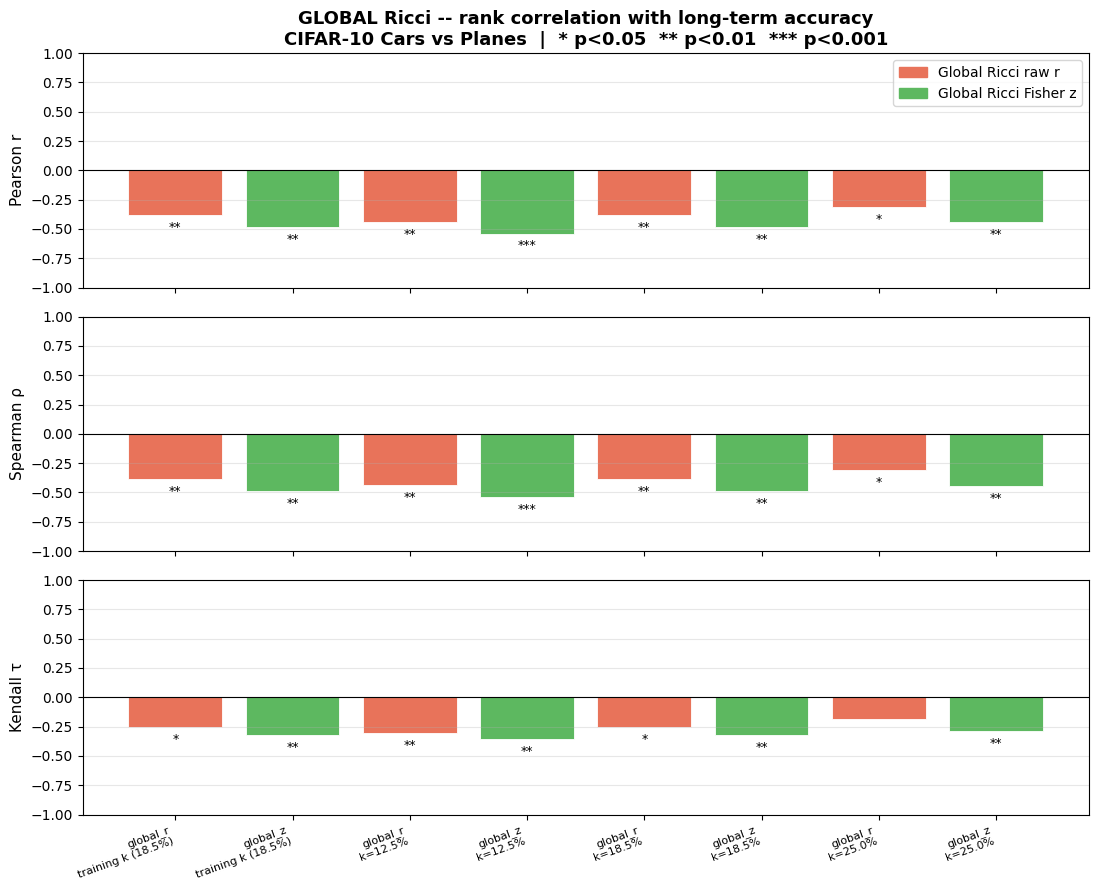

Saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/correlation_global_across_k.png


In [12]:
rows = load_json(os.path.join(OUTPUT_DIR, 'rank_correlation_table_global.json'), [])
if not rows:
    print('Run the rank correlation table cell first.')
else:
    def _stars(p):
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        return ''

    metric_color = {'global_r': '#E8735A', 'global_z': '#5DB860'}
    metric_label = {'global_r': 'Global Ricci raw r', 'global_z': 'Global Ricci Fisher z'}

    fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
    metrics = [('pearson_r',  'pearson_p',  'Pearson r'),
               ('spearman_r', 'spearman_p', 'Spearman \u03c1'),
               ('kendall_tau','kendall_p',  'Kendall \u03c4')]

    x = np.arange(len(rows))
    xticklabels = [f"{r['metric']}\n{r['k_label']}" for r in rows]

    for ax, (mkey, pkey, mlabel) in zip(axes, metrics):
        vals  = [r[mkey] for r in rows]
        pvals = [r[pkey] for r in rows]
        cols  = [metric_color[r['metric']] for r in rows]
        bars  = ax.bar(x, vals, color=cols, edgecolor='white', linewidth=0.6)
        for bar, p in zip(bars, pvals):
            s = _stars(p)
            if s:
                offset = 0.02 if bar.get_height() >= 0 else -0.05
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + offset, s,
                        ha='center', va='bottom' if bar.get_height() >= 0 else 'top',
                        fontsize=9)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_ylabel(mlabel, fontsize=11)
        ax.set_ylim(-1, 1); ax.grid(axis='y', alpha=0.3)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(xticklabels, fontsize=8, rotation=20, ha='right')
    handles = [mpatches.Patch(color=metric_color[m], label=metric_label[m])
               for m in ['global_r', 'global_z']]
    axes[0].legend(handles=handles, fontsize=10, loc='upper right')
    axes[0].set_title('GLOBAL Ricci -- rank correlation with long-term accuracy\n'
                      'CIFAR-10 Cars vs Planes  |  * p<0.05  ** p<0.01  *** p<0.001',
                      fontsize=13, fontweight='bold')

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'correlation_global_across_k.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {save_path}')
